# 02. Feature Engineering
Построение единого feature store без разделения на train/test. Здесь есть и таблицы, и графики по построенным признакам.

In [1]:

import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))
from src.utils import load_config, ensure_dir
from src.feature_engineering import infer_campaign_date, preprocess_clients, build_purchase_features_chunked, merge_all_features

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

config = load_config("../configs/config.yaml")
raw_dir = Path("..") / config["paths"]["raw_dir"]
fig_dir = ensure_dir(Path("..") / config["paths"]["figures_dir"])
tbl_dir = ensure_dir(Path("..") / config["paths"]["tables_dir"])
processed_dir = ensure_dir(Path("..") / config["paths"]["processed_dir"])
cols = config["columns"]


In [2]:

clients = pd.read_csv(raw_dir / config["files"]["clients"], parse_dates=[cols["first_issue_date"], cols["first_redeem_date"]], low_memory=False)
products = pd.read_csv(raw_dir / config["files"]["products"], low_memory=False)
uplift_train = pd.read_csv(raw_dir / config["files"]["uplift_train"], low_memory=False)
uplift_test = pd.read_csv(raw_dir / config["files"]["uplift_test"], low_memory=False)

print("clients:", clients.shape)
print("products:", products.shape)
print("uplift_train:", uplift_train.shape)
print("uplift_test:", uplift_test.shape)


clients: (400162, 5)
products: (43038, 11)
uplift_train: (200039, 3)
uplift_test: (200123, 1)


In [3]:

campaign_date = infer_campaign_date(clients, config)
campaign_date


Timestamp('2019-03-16 00:00:00')

In [4]:

clients_feat = preprocess_clients(clients, campaign_date, config)
display(clients_feat.head())
display(clients_feat.describe(include="all").T.head(15))


[clients] preprocessing started...
[clients] done, shape=(400162, 11)


,client_id,age,gender,days_since_first_issue,days_since_first_redeem,has_redeem_history,issue_to_redeem_days,age_missing,gender_is_female,gender_is_male,gender_is_unknown
0,000012768d,45,U,587,435.0,1,152.0,0,0,0,1
1,000036f903,72,F,704,691.0,1,12.0,0,1,0,0
2,000048b7a6,68,F,90,NaN,0,NaN,0,1,0,0
3,000073194a,60,F,661,476.0,1,184.0,0,1,0,0
4,00007c7133,67,U,662,74.0,1,588.0,0,0,0,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,400162,400162,000012768d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,400162.0,NaN,NaN,NaN,46.488112,43.871218,-7491.0,34.0,45.0,59.0,1901.0
gender,400162,3,U,185706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_first_issue,400162.0,NaN,NaN,NaN,429.916564,203.610115,0.0,268.0,484.0,602.0,710.0
days_since_first_redeem,364693.0,NaN,NaN,NaN,262.244861,218.570712,-250.0,70.0,282.0,446.0,703.0
has_redeem_history,400162.0,NaN,NaN,NaN,0.911363,0.284219,0.0,1.0,1.0,1.0,1.0
issue_to_redeem_days,364693.0,NaN,NaN,NaN,179.937284,156.381326,-43.0,62.0,132.0,252.0,948.0
age_missing,400162.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gender_is_female,400162.0,NaN,NaN,NaN,0.368973,0.482527,0.0,0.0,0.0,1.0,1.0
gender_is_male,400162.0,NaN,NaN,NaN,0.16695,0.372932,0.0,0.0,0.0,0.0,1.0


In [5]:

purchases_feat = build_purchase_features_chunked(
    purchases_path=raw_dir / config["files"]["purchases"],
    products=products,
    campaign_date=campaign_date,
    config=config,
)
display(purchases_feat.head())
print("purchases_feat shape:", purchases_feat.shape)


[purchases] reading in chunks from ../data/raw/purchases.csv
[purchases] chunk_size=500000
[purchases] chunk #1 loaded, rows=500,000, total_rows_seen=500,000
[purchases] chunk #1 after date filter: 485,540 rows
[purchases] chunk #1 processed
[purchases] chunk #2 loaded, rows=500,000, total_rows_seen=1,000,000
[purchases] chunk #2 after date filter: 485,602 rows
[purchases] chunk #2 processed
[purchases] chunk #3 loaded, rows=500,000, total_rows_seen=1,500,000
[purchases] chunk #3 after date filter: 485,959 rows
[purchases] chunk #3 processed
[purchases] chunk #4 loaded, rows=500,000, total_rows_seen=2,000,000
[purchases] chunk #4 after date filter: 485,522 rows
[purchases] chunk #4 processed
[purchases] chunk #5 loaded, rows=500,000, total_rows_seen=2,500,000
[purchases] chunk #5 after date filter: 486,131 rows
[purchases] chunk #5 processed
[purchases] chunk #6 loaded, rows=500,000, total_rows_seen=3,000,000
[purchases] chunk #6 after date filter: 486,165 rows
[purchases] chunk #6 pro

,client_id,rows_cnt,transaction_cnt,unique_product_cnt,unique_store_cnt,active_days,period_days,days_since_last_purchase,total_spent,total_quantity,avg_spent_per_line,avg_spent_per_transaction,avg_qty_per_line,avg_lines_per_transaction,purchase_frequency_per_active_day,category_top1_share,own_trademark_share,alcohol_share,total_points_received,total_points_spent,total_trn_sum_from_iss,total_trn_sum_from_red,category_diversity_proxy,spent_last_7d,trx_last_7d,unique_products_last_7d,spent_last_30d,trx_last_30d,unique_products_last_30d,spent_last_90d,trx_last_90d,unique_products_last_90d,log_total_spent,log_transaction_cnt,spend_trend_30_to_90,high_value_user,inactive_user,frequent_user,diverse_user
0,000012768d,52.0,4,46,3,4,103,1,40809.00,54.0,784.788462,10202.250000,1.038462,13.000000,1.0,0.519231,0.076923,0.000000,392.7,0.0,2805.0,0.0,0.884615,15362.0,2,21,15362.00,2,21,21676.00,3,29,10.616682,1.609438,0.708710,0,0,0,0
1,000036f903,156.0,31,94,5,31,100,6,56791.00,163.0,364.044872,1831.967742,1.044872,5.032258,1.0,0.544872,0.089744,0.006410,698.7,0.0,9481.0,0.0,0.602564,972.0,1,4,16402.00,9,36,48840.00,26,81,10.947151,3.465736,0.335831,0,0,1,0
2,000048b7a6,56.0,8,44,2,8,86,3,29724.00,91.0,530.785714,3715.500000,1.625000,7.000000,1.0,0.785714,0.053571,0.000000,218.8,0.0,3617.0,0.0,0.785714,684.0,1,2,2464.00,2,7,29724.00,8,44,10.299744,2.197225,0.082896,0,0,0,0
3,000073194a,79.0,16,68,1,16,95,14,61916.01,124.0,783.746962,3869.750625,1.569620,4.937500,1.0,0.531646,0.037975,0.113924,514.9,-576.0,9246.0,131.0,0.860759,0.0,0,0,22978.16,6,23,59220.53,12,60,11.033550,2.833213,0.388010,0,1,0,0
4,00007c7133,83.0,11,64,2,10,100,11,53998.72,83.0,650.586988,4908.974545,1.000000,7.545455,1.1,0.578313,0.120482,0.000000,459.7,-1680.0,6488.0,552.0,0.771084,0.0,0,0,3040.00,1,8,42321.72,7,50,10.896734,2.484907,0.071831,0,1,0,0


purchases_feat shape: (400162, 39)


In [6]:

full_feat = merge_all_features(
    uplift_train=uplift_train,
    uplift_test=uplift_test,
    clients_feat=clients_feat,
    purchases_feat=purchases_feat,
    config=config,
)
display(full_feat.head())
print("full_feat shape:", full_feat.shape)

full_feat.to_parquet(processed_dir / "full_features.parquet", index=False)


[merge] full base shape before features=(400162, 4)
[merge] full feature table shape=(400162, 52)


,client_id,treatment_flg,target,dataset_split,age,gender,days_since_first_issue,days_since_first_redeem,has_redeem_history,issue_to_redeem_days,age_missing,gender_is_female,gender_is_male,gender_is_unknown,rows_cnt,transaction_cnt,unique_product_cnt,unique_store_cnt,active_days,period_days,days_since_last_purchase,total_spent,total_quantity,avg_spent_per_line,avg_spent_per_transaction,avg_qty_per_line,avg_lines_per_transaction,purchase_frequency_per_active_day,category_top1_share,own_trademark_share,alcohol_share,total_points_received,total_points_spent,total_trn_sum_from_iss,total_trn_sum_from_red,category_diversity_proxy,spent_last_7d,trx_last_7d,unique_products_last_7d,spent_last_30d,trx_last_30d,unique_products_last_30d,spent_last_90d,trx_last_90d,unique_products_last_90d,log_total_spent,log_transaction_cnt,spend_trend_30_to_90,high_value_user,inactive_user,frequent_user,diverse_user
0,000012768d,0.0,1.0,train,45,U,587,435.0,1,152.0,0,0,0,1,52.0,4,46,3,4,103,1,40809.00,54.0,784.788462,10202.250000,1.038462,13.000000,1.000000,0.519231,0.076923,0.000000,392.7,0.0,2805.0,0.0,0.884615,15362.00,2,21,15362.00,2,21,21676.00,3,29,10.616682,1.609438,0.708710,0,0,0,0
1,000036f903,1.0,1.0,train,72,F,704,691.0,1,12.0,0,1,0,0,156.0,31,94,5,31,100,6,56791.00,163.0,364.044872,1831.967742,1.044872,5.032258,1.000000,0.544872,0.089744,0.006410,698.7,0.0,9481.0,0.0,0.602564,972.00,1,4,16402.00,9,36,48840.00,26,81,10.947151,3.465736,0.335831,0,0,1,0
2,00010925a5,1.0,1.0,train,83,U,234,182.0,1,51.0,0,0,0,1,78.0,18,58,2,17,102,7,28494.00,79.0,365.307692,1583.000000,1.012821,4.333333,1.058824,0.730769,0.115385,0.012821,163.0,-85.0,5873.0,438.0,0.743590,368.00,1,2,12816.00,8,27,24042.00,14,46,10.257484,2.944439,0.533067,0,1,0,0
3,0001f552b0,1.0,1.0,train,33,F,623,199.0,1,423.0,0,1,0,0,78.0,14,71,4,12,110,1,43879.62,97.0,562.559231,3134.258571,1.243590,5.571429,1.166667,0.641026,0.102564,0.000000,532.2,0.0,5643.0,0.0,0.910256,5757.91,3,13,7928.62,6,20,28811.49,11,50,10.689228,2.708050,0.275190,0,0,0,0
4,00020e7b18,1.0,1.0,train,73,U,473,429.0,1,44.0,0,0,0,1,272.0,18,175,4,16,112,0,558970.46,394.0,2055.038456,31053.914444,1.448529,15.111111,1.125000,0.500000,0.161765,0.000000,6088.0,-3004.0,25206.0,5885.0,0.643382,24942.28,2,17,147678.32,6,67,397060.11,13,127,13.233854,2.944439,0.371929,1,0,0,1


full_feat shape: (400162, 52)


In [7]:

feature_missing = (
    full_feat.isna().mean().sort_values(ascending=False).rename("missing_ratio").reset_index()
    .rename(columns={"index": "feature"})
)
feature_missing["missing_pct"] = (feature_missing["missing_ratio"] * 100).round(2)
display(feature_missing.head(20))
feature_missing.to_csv(tbl_dir / "feature_missing_report.csv", index=False)


,feature,missing_ratio,missing_pct
0,client_id,0.0,0.0
1,treatment_flg,0.0,0.0
2,category_top1_share,0.0,0.0
3,own_trademark_share,0.0,0.0
4,alcohol_share,0.0,0.0
5,total_points_received,0.0,0.0
6,total_points_spent,0.0,0.0
7,total_trn_sum_from_iss,0.0,0.0
8,total_trn_sum_from_red,0.0,0.0
9,category_diversity_proxy,0.0,0.0


In [8]:

numeric_cols = full_feat.select_dtypes(include=[np.number]).columns.tolist()
const_cols = [c for c in numeric_cols if full_feat[c].nunique(dropna=False) <= 1]
const_df = pd.DataFrame({"constant_features": const_cols})
display(const_df.head(20))
const_df.to_csv(tbl_dir / "constant_features.csv", index=False)


,constant_features
0,age_missing


In [9]:

important_cols = [c for c in [
    "dataset_split", cols["treatment"], cols["target"],
    "total_spent", "transaction_cnt", "unique_product_cnt",
    "days_since_last_purchase", "spent_last_7d", "spent_last_30d",
    "spent_last_90d", "high_value_user", "inactive_user", "frequent_user", "diverse_user"
] if c in full_feat.columns]
display(full_feat[important_cols].head(10))
full_feat[important_cols].head(50).to_csv(tbl_dir / "feature_sample_table.csv", index=False)


,dataset_split,treatment_flg,target,total_spent,transaction_cnt,unique_product_cnt,days_since_last_purchase,spent_last_7d,spent_last_30d,spent_last_90d,high_value_user,inactive_user,frequent_user,diverse_user
0,train,0.0,1.0,40809.00,4,46,1,15362.00,15362.00,21676.00,0,0,0,0
1,train,1.0,1.0,56791.00,31,94,6,972.00,16402.00,48840.00,0,0,1,0
2,train,1.0,1.0,28494.00,18,58,7,368.00,12816.00,24042.00,0,1,0,0
3,train,1.0,1.0,43879.62,14,71,1,5757.91,7928.62,28811.49,0,0,0,0
4,train,1.0,1.0,558970.46,18,175,0,24942.28,147678.32,397060.11,1,0,0,1
5,train,0.0,1.0,69487.58,15,70,3,9630.82,24100.80,53505.23,0,0,0,0
6,train,1.0,1.0,29335.46,32,67,2,1494.00,15898.64,25605.13,0,0,1,0
7,train,0.0,1.0,27800.86,12,55,6,747.03,16858.56,27158.26,0,0,0,0
8,train,0.0,1.0,73844.96,29,98,1,2506.00,41221.69,73844.96,0,0,1,0
9,train,0.0,0.0,17545.52,3,25,13,0.00,10218.00,17545.52,0,1,0,0


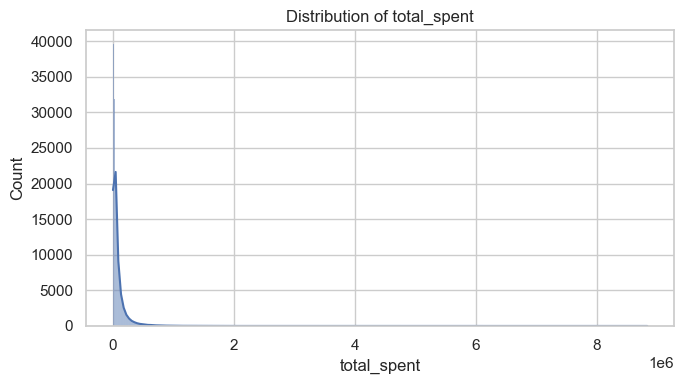

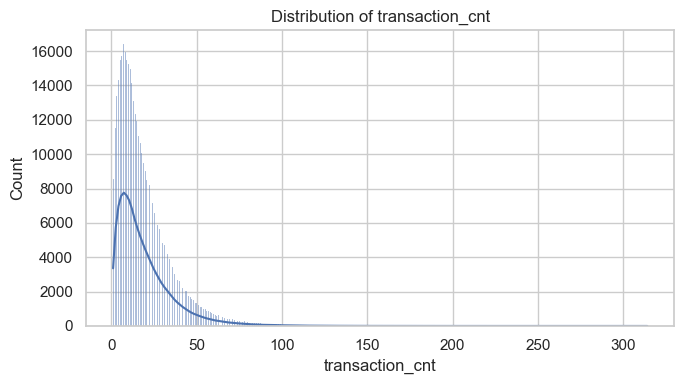

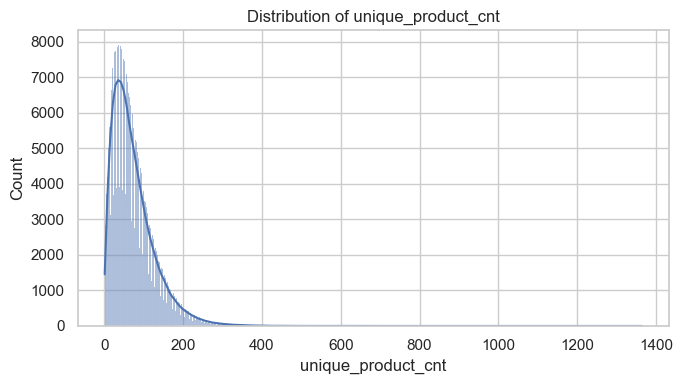

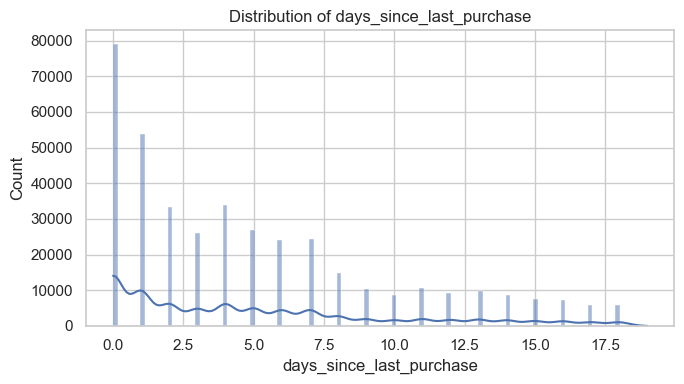

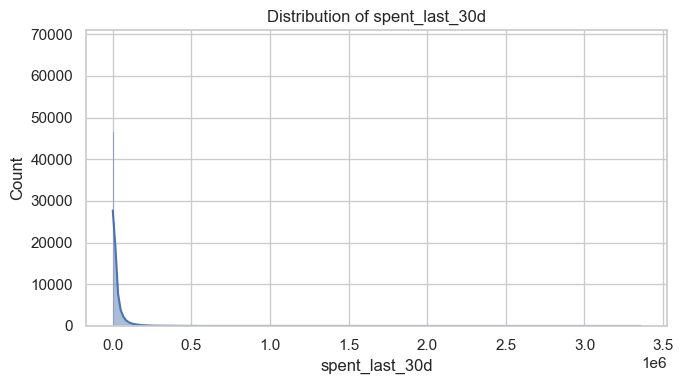

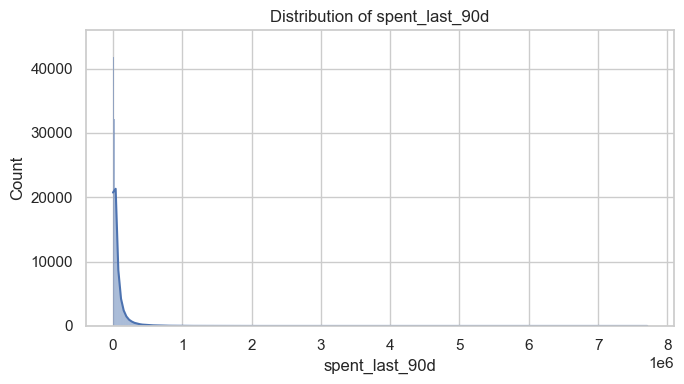

In [10]:

plot_features = [c for c in [
    "total_spent", "transaction_cnt", "unique_product_cnt",
    "days_since_last_purchase", "spent_last_30d", "spent_last_90d"
] if c in full_feat.columns]

for col in plot_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(full_feat[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.savefig(fig_dir / f"fe_hist_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()


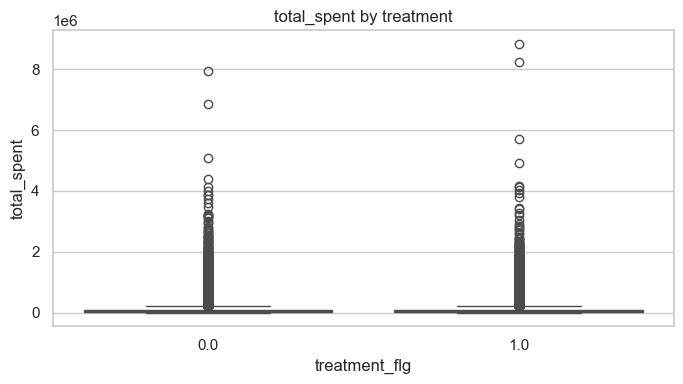

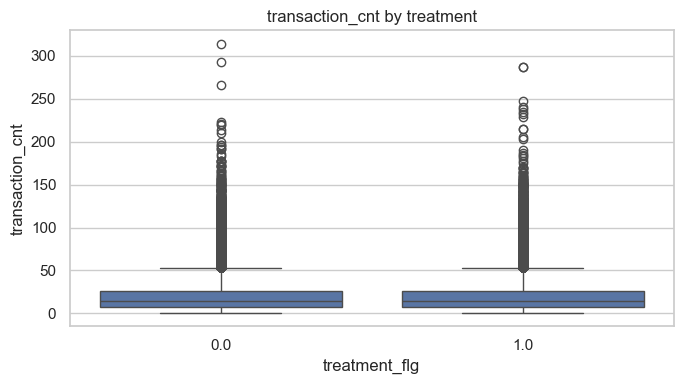

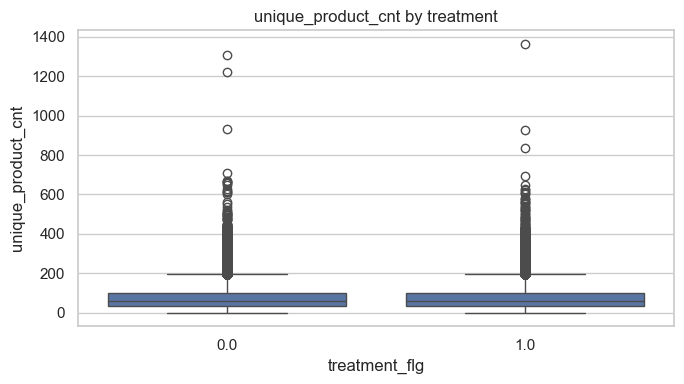

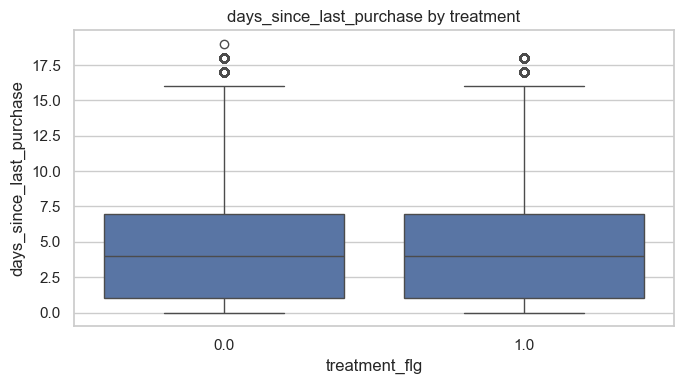

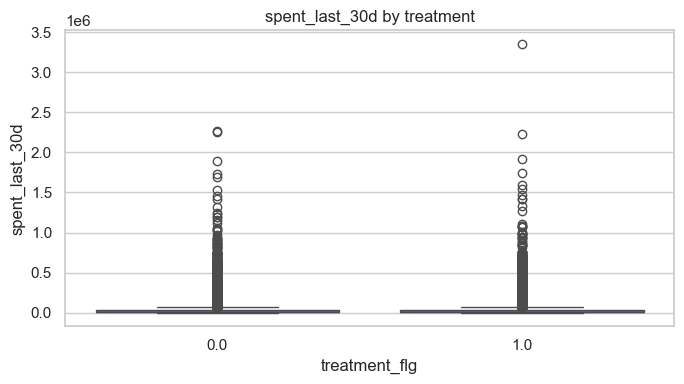

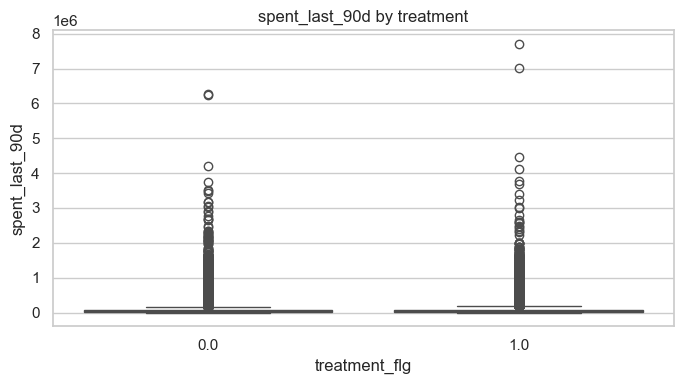

In [11]:

if cols["treatment"] in full_feat.columns:
    fe_train = full_feat[full_feat["dataset_split"] == "train"].copy()

    for col in plot_features:
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=fe_train, x=cols["treatment"], y=col)
        plt.title(f"{col} by treatment")
        plt.tight_layout()
        plt.savefig(fig_dir / f"fe_box_{col}_by_treatment.png", dpi=150, bbox_inches="tight")
        plt.show()


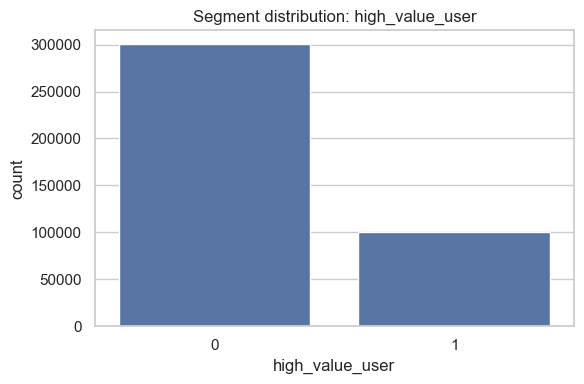

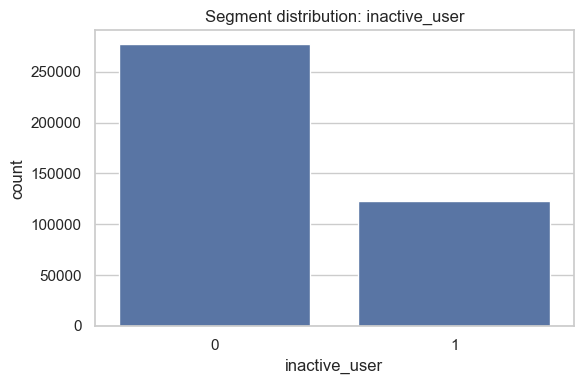

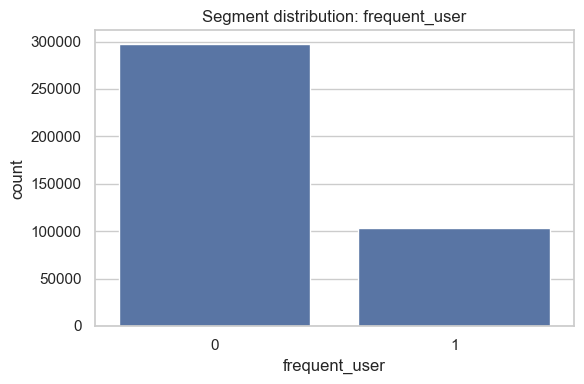

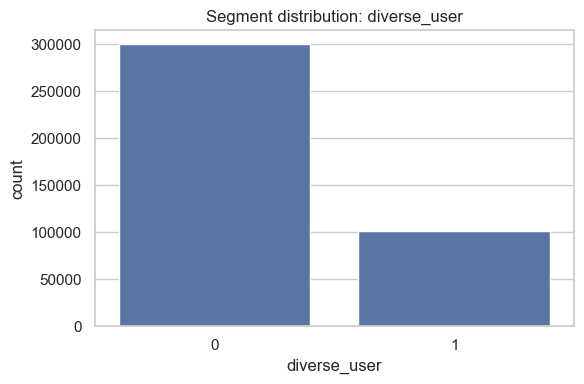

In [12]:

segment_cols = [c for c in ["high_value_user", "inactive_user", "frequent_user", "diverse_user"] if c in full_feat.columns]
for col in segment_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=full_feat, x=col)
    plt.title(f"Segment distribution: {col}")
    plt.tight_layout()
    plt.savefig(fig_dir / f"fe_segment_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [13]:

summary_stats = full_feat[plot_features].describe().T
display(summary_stats)
summary_stats.to_csv(tbl_dir / "feature_summary_stats.csv")


,count,mean,std,min,25%,50%,75%,max
total_spent,400162.0,86521.767233,155433.742141,2.10,18034.9575,42738.025,94016.1050,8835890.93
transaction_cnt,400162.0,19.542838,17.275667,1.00,8.0000,15.000,26.0000,314.00
unique_product_cnt,400162.0,73.588252,55.219668,1.00,34.0000,61.000,99.0000,1364.00
days_since_last_purchase,400162.0,4.982739,4.880141,0.00,1.0000,4.000,7.0000,19.00
spent_last_30d,400162.0,28227.588319,52698.112503,1.97,4425.2825,12660.795,30868.4275,3357507.80
spent_last_90d,400162.0,71850.133097,129743.437355,1.97,14489.0000,34914.000,78118.5825,7709846.22


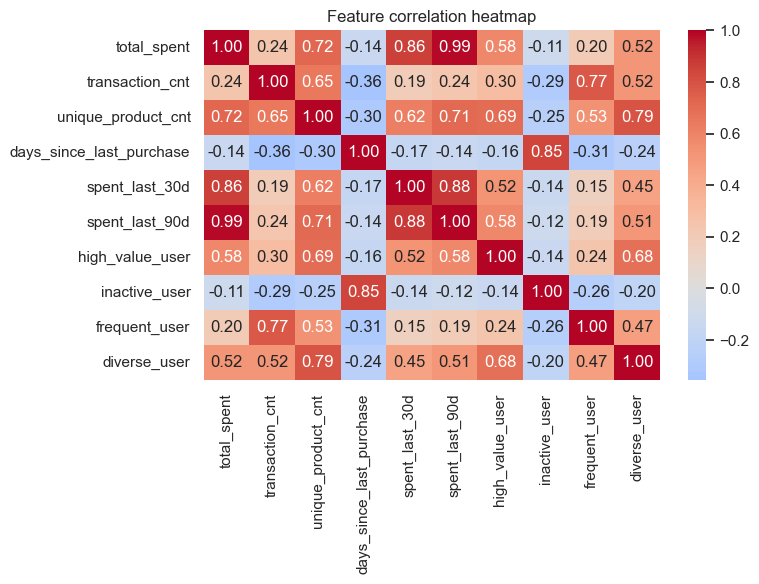

In [14]:

corr_cols = [c for c in plot_features + segment_cols if c in full_feat.columns]
corr = full_feat[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.savefig(fig_dir / "fe_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Выводы
Здесь можно зафиксировать, какие признаки наиболее содержательны, где распределения скошены и что стоит использовать на этапе моделирования.